In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 41.5 MB/s et

In [2]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
!pip install torchinfo

In [4]:
#############################################
# 1. Import Libraries & Mount Drive
#############################################
import os
import time
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
from torchinfo import summary  # For detailed model summary

# Mount Google Drive
drive.mount('/content/drive')

#############################################
# 2. Data Loading Function
#############################################
def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    return train_loader, val_loader, test_loader

#############################################
# 3. Define Training and Evaluation Functions
#############################################
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # Validation step
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation curves
    plt.figure(figsize=(12, 5))

    # 1) Loss Curves
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='o')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # For example, if your loss is around 0.0 to 0.1, fix the y-limit:
    plt.ylim([0.0, 2.0])  # Adjust based on your loss values

    # 2) Accuracy Curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy', marker='o')
    plt.plot(val_accs, label='Val Accuracy', marker='o')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    # If your accuracy is in the 98–100% range, fix the y-limit:
    plt.ylim([85, 100])  # Adjust as needed

    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_loader, device, class_names):
    best_model_path = 'best_model.pth'
    model.load_state_dict(torch.load(best_model_path))
    model.to(device)
    model.eval()
    y_true, y_pred = [], []
    total, correct = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

Mounted at /content/drive


In [5]:
def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=16):
    model.load_state_dict(torch.load('best_model.pth'))
    model.to(device).eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    # Plot true vs predicted images in a 4x4 grid
    plt.figure(figsize=(12, 12))  # Adjust figure size for 16 images
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Clip to valid image range

        plt.subplot(4, 4, idx + 1)  # 4 rows, 4 columns
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)  # Smaller font size
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [23]:
class GradCAMWrapper:
    def __init__(self, model):
        self.model = model
        # Access features directly from the model
        self.target_layers = [self.model.features[-1]]
        self.cam = GradCAM(model=self.model,
                          target_layers=self.target_layers,
                          #use_cuda=torch.cuda.is_available()
                          )

    def visualize(self, input_tensor, rgb_img=None):
        grayscale_cam = self.cam(input_tensor=input_tensor)
        grayscale_cam = grayscale_cam[0, :]

        if rgb_img is None:
            rgb_img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
            rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        return visualization

def show_gradcam_examples(model, test_loader, device, num_examples=16):
    cam = GradCAMWrapper(model)
    model.eval()

    # Get a batch of test data
    inputs, labels = next(iter(test_loader))
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    # Plot Grad-CAM visualizations in a 4x4 grid
    plt.figure(figsize=(12, 12))  # Adjust figure size for 16 images
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)  # Clip to valid image range

        # Generate Grad-CAM visualization
        visualization = cam.visualize(inputs[idx].unsqueeze(0), img)

        plt.subplot(4, 4, idx + 1)  # 4 rows, 4 columns
        plt.imshow(visualization)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)  # Smaller font size
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
#############################################
# 4. Set Paths, Extract Dataset & Create Data Loaders
#############################################
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes
print("Classes:", class_names)

Classes: ['betel_Bacterial Leaf Disease', 'betel_Dried Leaf', 'betel_Fungal Brown Spot Disease', 'betel_Healthy Leaf', 'tea_algal_spot', 'tea_brown_blight', 'tea_gray_blight', 'tea_healthy', 'tea_helopeltis', 'tea_red_spot']


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
#############################################
# 5. Load Pre-trained MobileNetV3 Small & Modify Classifier
#############################################
# Use MobileNetV3 Small instead of Large
model = models.mobilenet_v3_small(pretrained=True)

# Print detailed model architecture and summary before modification
print("\nDetailed Model Architecture (Before modification):")
print(model)
print("\nModel Summary (Before modification):")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 78.1MB/s]



Detailed Model Architecture (Before modification):
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 1000]                 --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           744
│    └─InvertedResidual: 2-3                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           3,864
│    └─InvertedResidual: 2-4                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-6   

In [10]:
# Replace the final layer (assumes model.classifier is a Sequential module)
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, num_classes)

# Print updated model architecture and summary after modifying the classifier
print("\nDetailed Model Architecture (After modifying classifier):")
print(model)
print("\nUpdated Model Summary (After modifying classifier):")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Detailed Model Architecture (After modifying classifier):
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormAct

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           744
│    └─InvertedResidual: 2-3                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           3,864
│    └─InvertedResidual: 2-4                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-6   

In [11]:
criterion = nn.CrossEntropyLoss()


Stage 1: Training only classifier layers
Epoch 1/15 | Train Loss: 0.6558 Acc: 78.29% | Val Loss: 0.3168 Acc: 89.46% | Time: 23.74s | 290.96 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/15 | Train Loss: 0.3424 Acc: 88.10% | Val Loss: 0.2682 Acc: 90.93% | Time: 22.50s | 306.92 samples/s
Best model saved to best_model.pth
Epoch 3/15 | Train Loss: 0.2978 Acc: 89.27% | Val Loss: 0.2696 Acc: 90.26% | Time: 23.54s | 293.33 samples/s
Epoch 4/15 | Train Loss: 0.2760 Acc: 90.01% | Val Loss: 0.2359 Acc: 92.48% | Time: 22.54s | 306.42 samples/s
Best model saved to best_model.pth
Epoch 5/15 | Train Loss: 0.2454 Acc: 91.14% | Val Loss: 0.2181 Acc: 92.68% | Time: 22.76s | 303.46 samples/s
Best model saved to best_model.pth
Epoch 6/15 | Train Loss: 0.2174 Acc: 91.86% | Val Loss: 0.2334 Acc: 92.28% | Time: 23.20s | 297.68 samples/s
Epoch 7/15 | Train Loss: 0.2106 Acc: 92.46% | Val Loss: 0.2239 Acc: 92.81% | Time: 21.89s | 315.54 samples/s
Best model saved to best_model.pth
Epoch 8/15 | Train Loss: 0.1993 Acc: 93.01% | Val Loss: 0.2156 Acc: 93.49% | Time: 23.87s | 289.31 samples/s
Best model saved to best_model.pth
Epoch 9/15 | Train Loss: 0.1869 Acc: 93.12% | Val Loss: 0.1985

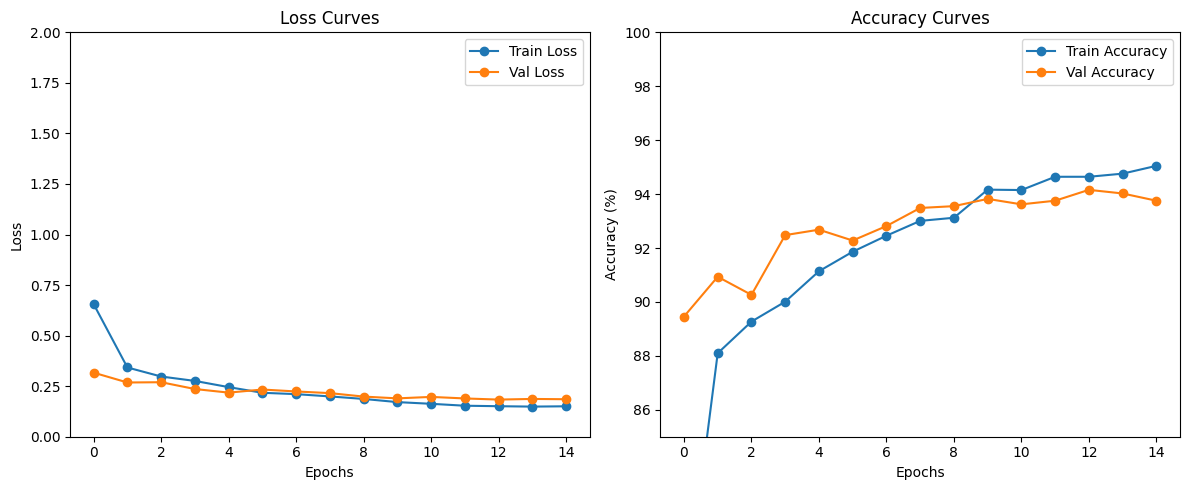

In [12]:
#############################################
# 6. Stage 1: Train Only the Classification Layers
#############################################
print("\nStage 1: Training only classifier layers")
# Freeze feature extractor layers
for param in model.features.parameters():
    param.requires_grad = False

optimizer_stage1 = optim.Adam(model.classifier.parameters(), lr=3e-4)
scheduler = CosineAnnealingLR(optimizer_stage1, T_max=15)
train_model(model, train_loader, val_loader, num_epochs=15, optimizer=optimizer_stage1,
            criterion=criterion, device=device, scheduler=scheduler)

In [13]:
# Analyze the model after Stage 1 training
print("\nModel Analysis After Stage 1 Training:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis After Stage 1 Training:


Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           (744)
│    └─InvertedResidual: 2-3                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           (3,864)
│    └─InvertedResidual: 2-4                       [1, 24, 32, 32]           --
│    │    └─Sequential

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Test Accuracy: 93.55%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.92      0.83      0.87       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.93      1.00      0.96       148
             betel_Healthy Leaf       0.91      0.93      0.92       148
                 tea_algal_spot       0.98      0.97      0.98       150
               tea_brown_blight       0.86      0.93      0.90       130
                tea_gray_blight       0.89      0.89      0.89       150
                    tea_healthy       0.93      0.94      0.93       150
                 tea_helopeltis       0.95      0.89      0.92       150
                   tea_red_spot       0.98      0.97      0.98       150

                       accuracy                           0.94      1472
                      macro avg       0.94      0.94      0.93      1472
  

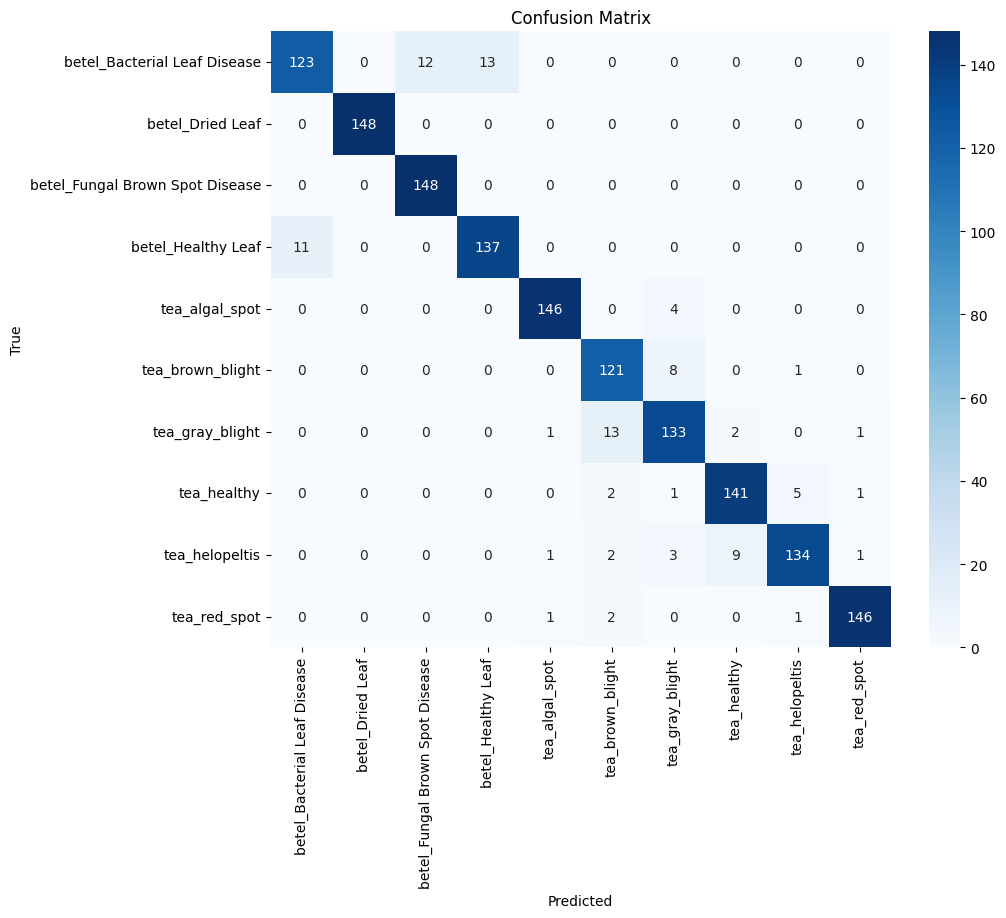

In [15]:
evaluate_model(model, test_loader, device, class_names)

In [16]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [17]:
show_gradcam_examples(model, test_loader, device)

AttributeError: 'MobileNetV3' object has no attribute 'model'

In [18]:
#############################################
# 7. Stage 2: Fine-tune by Unfreezing Last 20 Layers
#############################################
print("\nStage 2: Fine-tuning last 20 layers")
# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last 50 parameters (from the list of named parameters)
named_params = list(model.named_parameters())
for name, param in named_params[-20:]:
    param.requires_grad = True
    print(f"Unfreezing: {name}")


Stage 2: Fine-tuning last 20 layers
Unfreezing: features.11.block.0.0.weight
Unfreezing: features.11.block.0.1.weight
Unfreezing: features.11.block.0.1.bias
Unfreezing: features.11.block.1.0.weight
Unfreezing: features.11.block.1.1.weight
Unfreezing: features.11.block.1.1.bias
Unfreezing: features.11.block.2.fc1.weight
Unfreezing: features.11.block.2.fc1.bias
Unfreezing: features.11.block.2.fc2.weight
Unfreezing: features.11.block.2.fc2.bias
Unfreezing: features.11.block.3.0.weight
Unfreezing: features.11.block.3.1.weight
Unfreezing: features.11.block.3.1.bias
Unfreezing: features.12.0.weight
Unfreezing: features.12.1.weight
Unfreezing: features.12.1.bias
Unfreezing: classifier.0.weight
Unfreezing: classifier.0.bias
Unfreezing: classifier.3.weight
Unfreezing: classifier.3.bias


Epoch 1/15 | Train Loss: 0.2007 Acc: 92.57% | Val Loss: 0.1779 Acc: 94.09% | Time: 23.51s | 293.74 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/15 | Train Loss: 0.1405 Acc: 94.80% | Val Loss: 0.1892 Acc: 94.02% | Time: 22.51s | 306.75 samples/s
Epoch 3/15 | Train Loss: 0.1095 Acc: 96.02% | Val Loss: 0.1634 Acc: 94.76% | Time: 23.95s | 288.30 samples/s
Best model saved to best_model.pth
Epoch 4/15 | Train Loss: 0.0752 Acc: 97.34% | Val Loss: 0.2139 Acc: 94.02% | Time: 23.79s | 290.26 samples/s
Epoch 5/15 | Train Loss: 0.0669 Acc: 97.71% | Val Loss: 0.2013 Acc: 93.35% | Time: 22.74s | 303.66 samples/s
Epoch 6/15 | Train Loss: 0.0536 Acc: 98.25% | Val Loss: 0.1629 Acc: 95.63% | Time: 23.98s | 287.99 samples/s
Best model saved to best_model.pth
Epoch 7/15 | Train Loss: 0.0449 Acc: 98.42% | Val Loss: 0.1548 Acc: 95.57% | Time: 24.05s | 287.15 samples/s
Epoch 8/15 | Train Loss: 0.0343 Acc: 98.84% | Val Loss: 0.1332 Acc: 96.24% | Time: 22.71s | 304.07 samples/s
Best model saved to best_model.pth
Epoch 9/15 | Train Loss: 0.0284 Acc: 99.16% | Val Loss: 0.1718 Acc: 95.37% | Time: 23.69s | 291.57 samples/s
Epoch 10/15 | Train Los

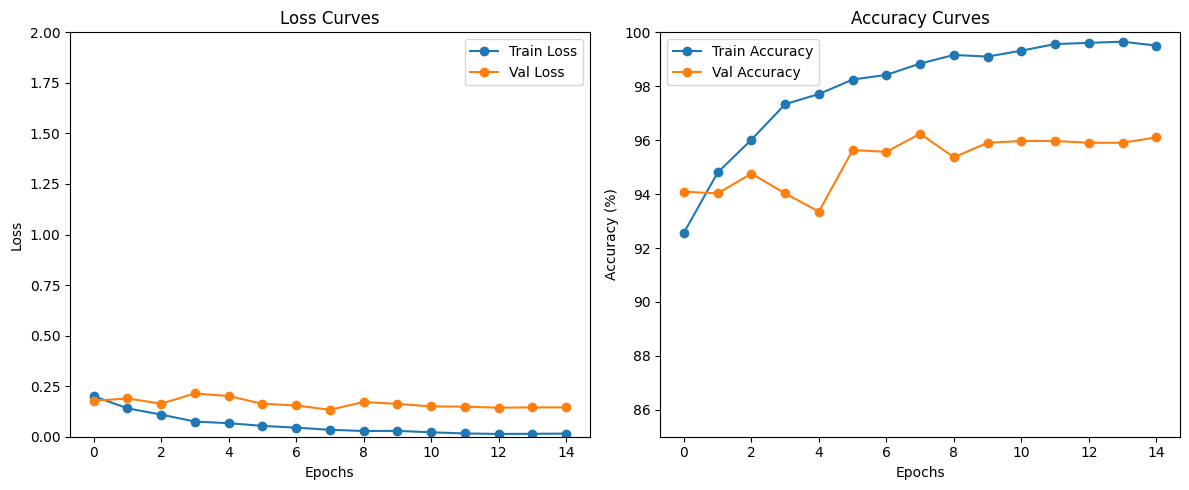

In [19]:
params_to_update = [param for param in model.parameters() if param.requires_grad]
optimizer_stage2 = optim.Adam(params_to_update, lr=3e-4)
scheduler = CosineAnnealingLR(optimizer_stage2, T_max=15)
train_model(model, train_loader, val_loader, num_epochs=15, optimizer=optimizer_stage2,
            criterion=criterion, device=device, scheduler=scheduler)

In [20]:
# Analyze the model after Stage 2 training
print("\nModel Analysis After Stage 2 Training:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis After Stage 2 Training:


Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           (744)
│    └─InvertedResidual: 2-3                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           (3,864)
│    └─InvertedResidual: 2-4                       [1, 24, 32, 32]           --
│    │    └─Sequential


Test Accuracy: 96.06%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.90      0.87      0.88       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.93      1.00      0.96       148
             betel_Healthy Leaf       0.94      0.90      0.92       148
                 tea_algal_spot       1.00      0.99      1.00       150
               tea_brown_blight       0.93      0.98      0.95       130
                tea_gray_blight       0.97      0.93      0.95       150
                    tea_healthy       0.97      0.97      0.97       150
                 tea_helopeltis       0.97      0.97      0.97       150
                   tea_red_spot       0.99      0.99      0.99       150

                       accuracy                           0.96      1472
                      macro avg       0.96      0.96      0.96      1472
  

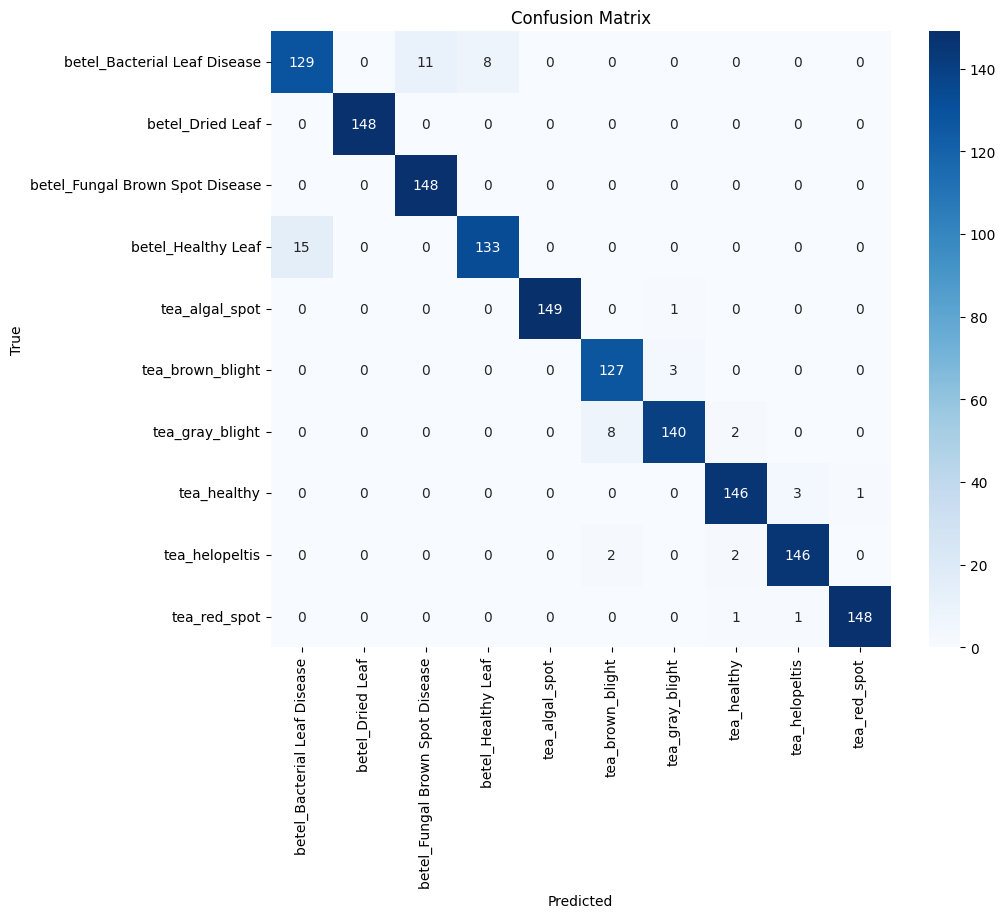

In [21]:
evaluate_model(model, test_loader, device, class_names)

In [22]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [24]:
show_gradcam_examples(model, test_loader, device)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
ttt


Stage 3: Retraining the entire model


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/10 | Train Loss: 0.0144 Acc: 99.61% | Val Loss: 0.1435 Acc: 96.17% | Time: 27.42s | 251.84 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/10 | Train Loss: 0.0117 Acc: 99.65% | Val Loss: 0.1294 Acc: 96.64% | Time: 27.55s | 250.71 samples/s
Best model saved to best_model.pth
Epoch 3/10 | Train Loss: 0.0112 Acc: 99.62% | Val Loss: 0.1323 Acc: 96.57% | Time: 27.41s | 251.99 samples/s
Epoch 4/10 | Train Loss: 0.0091 Acc: 99.75% | Val Loss: 0.1283 Acc: 96.51% | Time: 27.29s | 253.04 samples/s
Epoch 5/10 | Train Loss: 0.0087 Acc: 99.75% | Val Loss: 0.1281 Acc: 96.57% | Time: 27.38s | 252.25 samples/s
Epoch 6/10 | Train Loss: 0.0093 Acc: 99.81% | Val Loss: 0.1296 Acc: 96.78% | Time: 27.33s | 252.71 samples/s
Best model saved to best_model.pth
Epoch 7/10 | Train Loss: 0.0092 Acc: 99.75% | Val Loss: 0.1251 Acc: 96.84% | Time: 27.67s | 249.60 samples/s
Best model saved to best_model.pth
Epoch 8/10 | Train Loss: 0.0136 Acc: 99.57% | Val Loss: 0.1247 Acc: 96.71% | Time: 27.56s | 250.54 samples/s
Epoch 9/10 | Train Loss: 0.0072 Acc: 99.84% | Val Loss: 0.1256 Acc: 96.84% | Time: 27.68s | 249.52 samples/s
Epoch 10/10 | Train Los

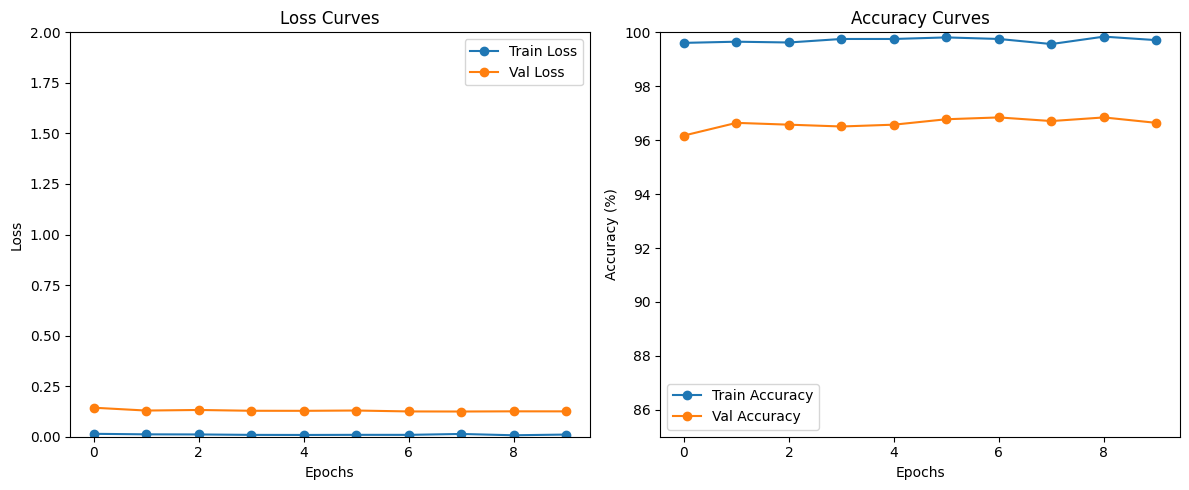

In [ ]:
#############################################
# 8. Stage 3: Retrain the Entire Model
#############################################
print("\nStage 3: Retraining the entire model")
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer_stage3 = optim.Adam(model.parameters(), lr=1e-5)
scheduler = CosineAnnealingLR(optimizer_stage3, T_max=10)
train_model(model, train_loader, val_loader, num_epochs=10, optimizer=optimizer_stage3,
            criterion=criterion, device=device, scheduler=scheduler)

In [ ]:
# Analyze the model after Stage 3 training
print("\nModel Analysis After Stage 3 Training:")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Model Analysis After Stage 3 Training:


Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 576, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2                       [1, 16, 64, 64]           --
│    │    └─Sequential: 3-4                        [1, 16, 64, 64]           744
│    └─InvertedResidual: 2-3                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-5                        [1, 24, 32, 32]           3,864
│    └─InvertedResidual: 2-4                       [1, 24, 32, 32]           --
│    │    └─Sequential: 3-6   


Test Accuracy: 97.15%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.92      0.92      0.92       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.97      1.00      0.98       148
             betel_Healthy Leaf       0.95      0.92      0.93       148
                 tea_algal_spot       1.00      0.99      1.00       150
               tea_brown_blight       0.93      1.00      0.96       130
                tea_gray_blight       0.99      0.96      0.98       150
                    tea_healthy       0.97      0.99      0.98       150
                 tea_helopeltis       0.99      0.96      0.97       150
                   tea_red_spot       0.99      0.98      0.99       150

                       accuracy                           0.97      1472
                      macro avg       0.97      0.97      0.97      1472
  

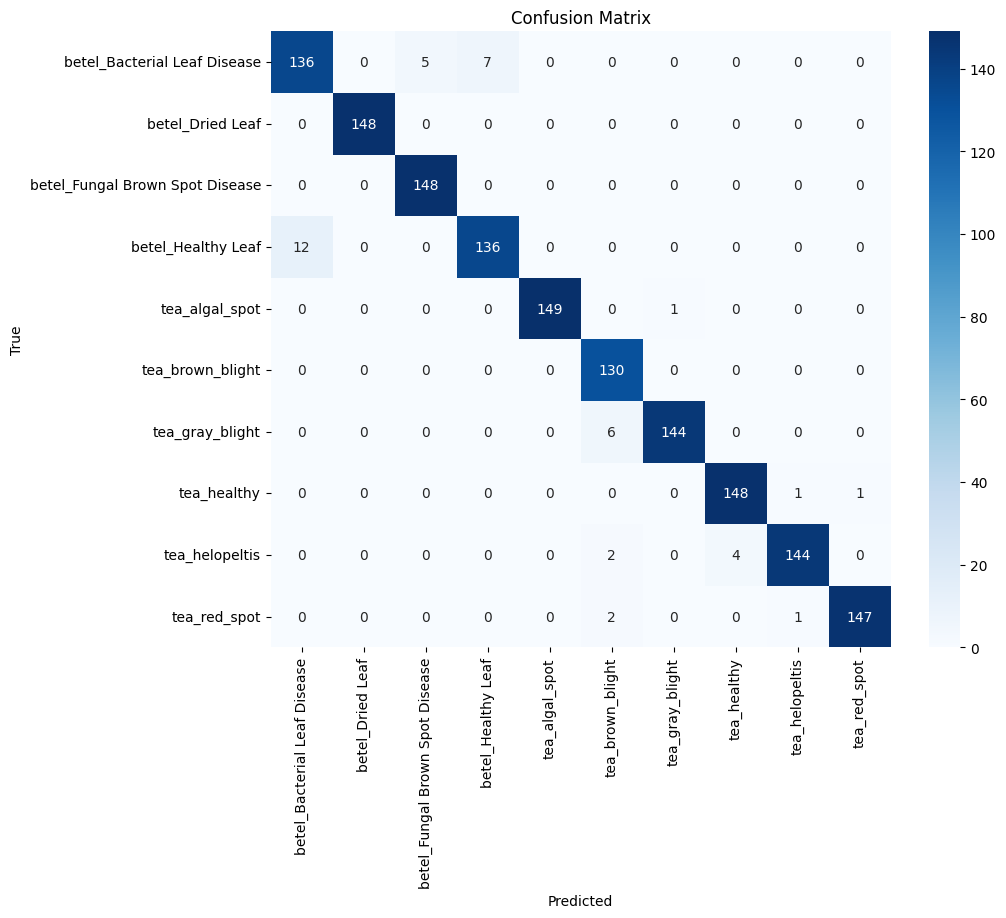

In [ ]:
evaluate_model(model, test_loader, device, class_names)